In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

In [2]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [3]:
data = pd.read_csv('insurance.csv')

# EDA 

In [4]:
data.shape

(1338, 7)

In [5]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
numeric_cols = data.select_dtypes(include=np.number).columns
numeric_cols

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

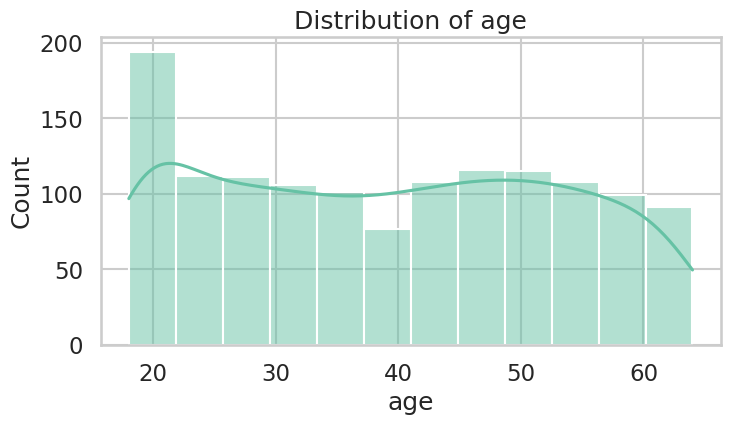

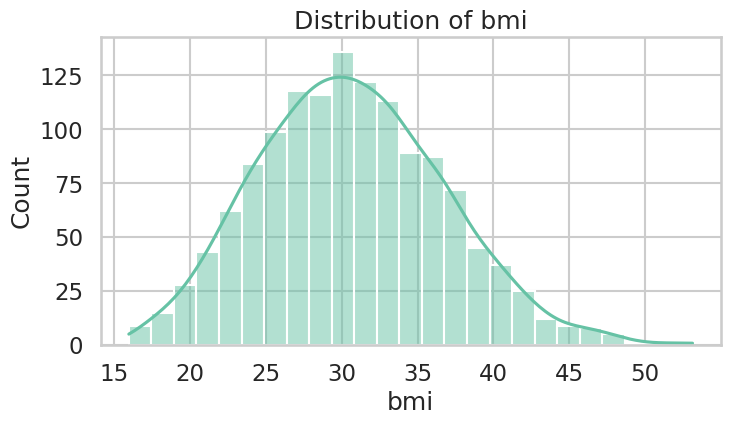

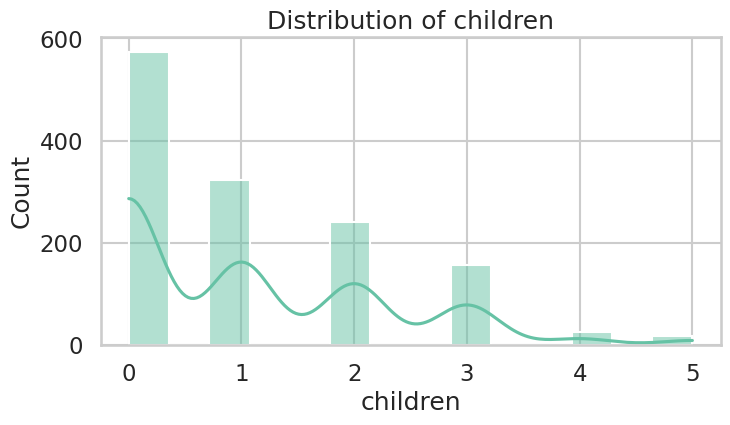

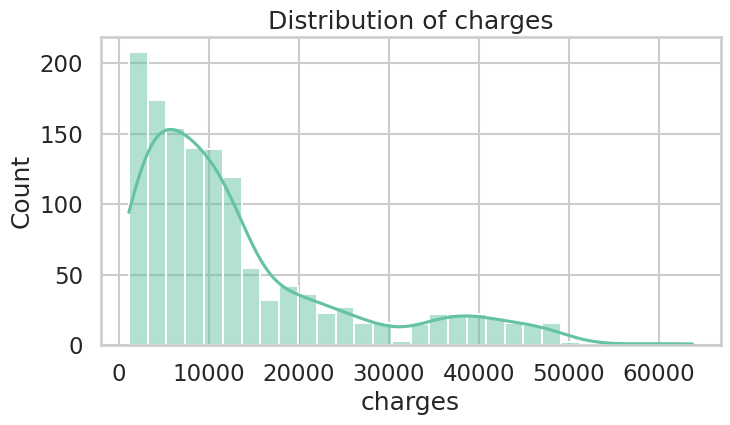

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

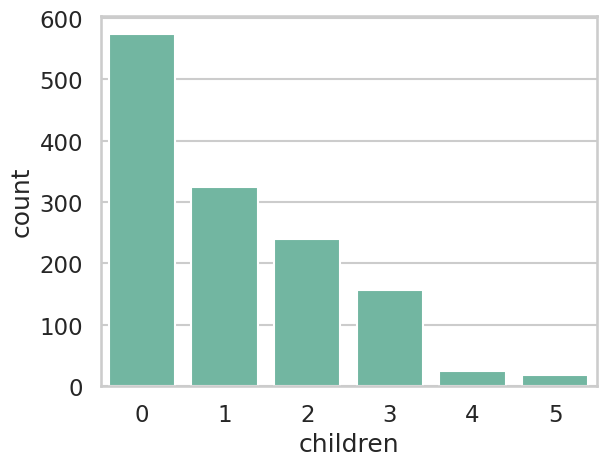

In [11]:
sns.countplot(x = data['children'])

<Axes: xlabel='sex', ylabel='count'>

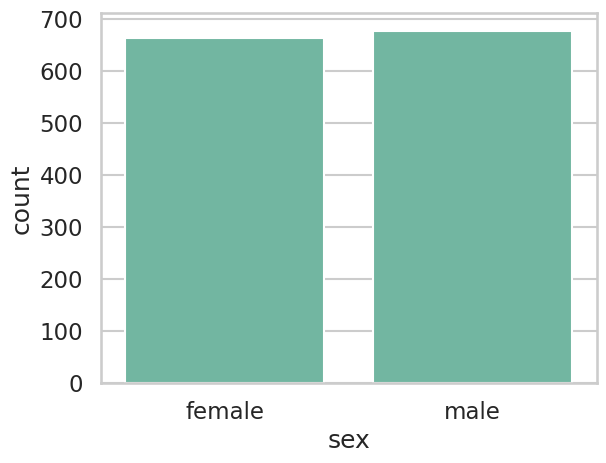

In [12]:
sns.countplot(x= data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

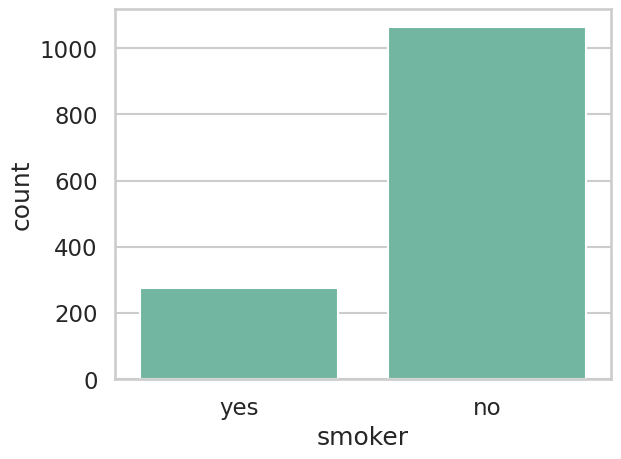

In [13]:
sns.countplot(x= data['smoker'])

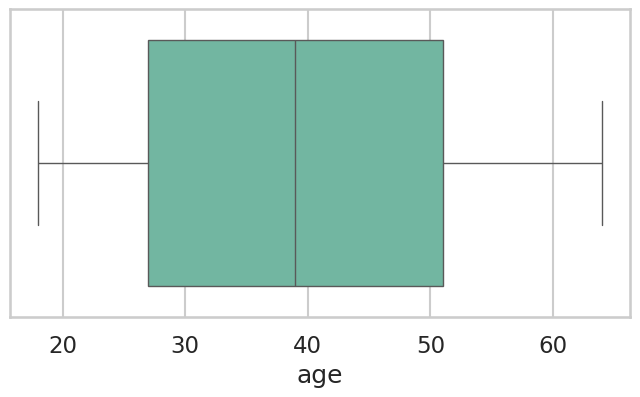

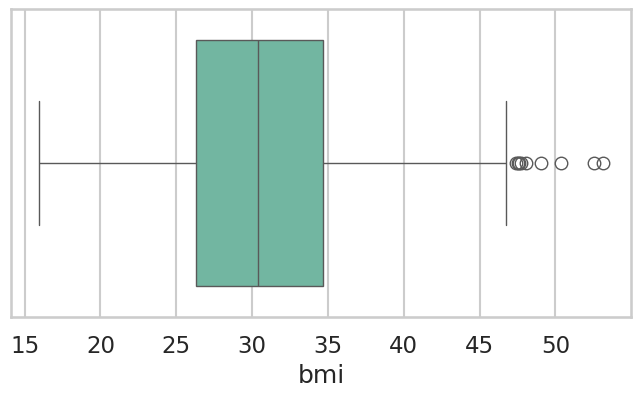

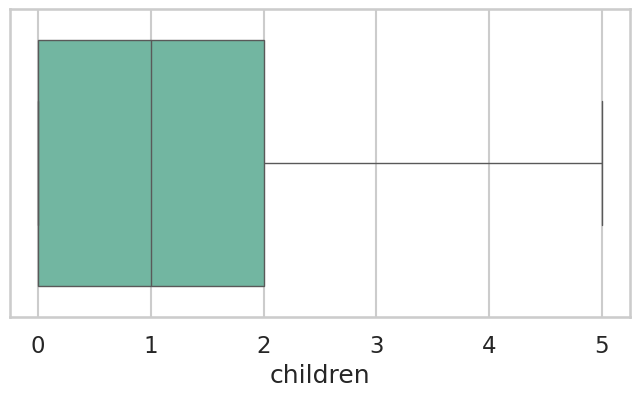

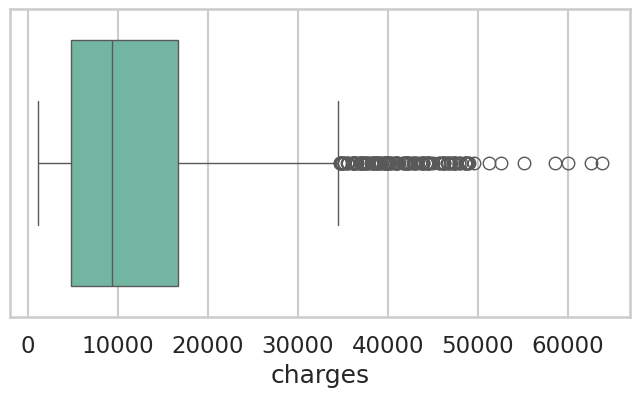

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x = data[col])
    plt.show()

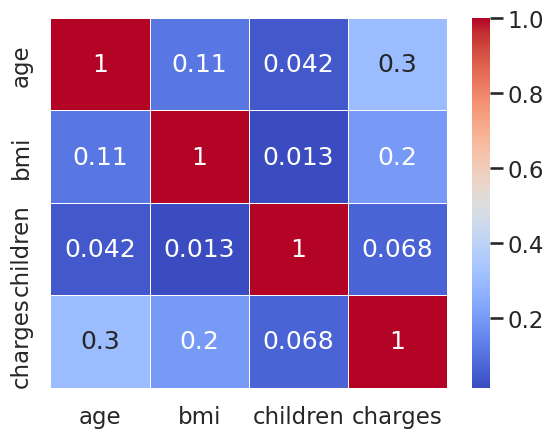

In [15]:
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Data Cleaning and preprocessing 

In [16]:
data_cleaned = data.copy()

In [17]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
data_cleaned.drop_duplicates(inplace=True)

In [19]:
data_cleaned.shape

(1337, 7)

In [20]:
data_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
data_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [22]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [23]:
data_cleaned['sex'] = data_cleaned['sex'].map({'male': 0, 
                                               'female': 1}, inplace = True)

In [24]:
data_cleaned.rename(columns = {'sex': 'is_female'} , inplace = True)

In [25]:
data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [26]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'no': 0,
                                                   'yes': 1}, inplace = True)

In [27]:
data_cleaned.rename(columns = {'smoker': 'is_smoker'} , inplace = True)

In [28]:
data_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [29]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['region'], prefix='region',  dtype = int)

In [30]:
data_cleaned 

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


In [31]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


# Feature Engineering and Extraction

In [32]:
data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


In [33]:
data_cleaned['bmi_category'] = pd.cut(data_cleaned['bmi'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])

In [34]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal weight
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight


In [35]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['bmi_category'], prefix='bmi_category', dtype = int)

In [36]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0


# Test train split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = data_cleaned.drop('charges', axis=1)
y = data_cleaned['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# feature scaling

**Using library**

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['age', 'bmi', 'children']

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [40]:
data_cleaned.corr(numeric_only = True)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
age,1.000000,0.019814,0.109344,0.041536,-0.025587,0.298308,0.001868,0.001495,-0.012311,0.009415,-0.061557,-0.074800,-0.018075,0.087881
is_female,0.019814,1.000000,-0.046397,-0.017848,-0.076596,-0.058044,0.002008,0.012482,-0.017578,0.003767,0.031307,0.024343,0.019400,-0.043676
bmi,0.109344,-0.046397,1.000000,0.012755,0.003746,0.198401,-0.138178,-0.136138,0.270057,-0.006211,-0.270385,-0.592272,-0.317070,0.799681
children,0.041536,-0.017848,0.012755,1.000000,0.007331,0.067389,-0.023202,0.026044,-0.023492,0.021538,-0.005044,0.010538,-0.020481,0.011935
is_smoker,-0.025587,-0.076596,0.003746,0.007331,1.000000,0.787234,0.002597,-0.036321,0.068282,-0.037168,0.010377,0.018216,-0.016787,-0.001021
charges,0.298308,-0.058044,0.198401,0.067389,0.787234,1.000000,0.005945,-0.038695,0.073578,-0.043637,-0.048225,-0.105946,-0.120059,0.200501
region_northeast,0.001868,0.002008,-0.138178,-0.023202,0.002597,0.005945,1.000000,-0.319842,-0.345909,-0.320493,0.068942,0.084916,0.017176,-0.096498
region_northwest,0.001495,0.012482,-0.136138,0.026044,-0.036321,-0.038695,-0.319842,1.000000,-0.345909,-0.320493,0.026827,0.038343,0.051843,-0.082515
region_southeast,-0.012311,-0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,-0.345909,1.000000,-0.346614,-0.077264,-0.092040,-0.093030,0.172763
region_southwest,0.009415,0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.320493,-0.346614,1.000000,-0.015492,-0.027619,0.027591,-0.000452


# Pearsonr correlation and Chi - squared test for feature selection

In [41]:
from scipy.stats import pearsonr

targeted_cols = ['age', 'bmi', 'children', 
                 'is_female', 'is_smoker', 'region_northwest',
                 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 
                 'bmi_category_Overweight', 'bmi_category_Obese']

correlation = {
    feature : pearsonr(X_train[feature], y_train)[0] 
    for feature in targeted_cols
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation with Charges'])
correlation_df.sort_values(by='Correlation with Charges', ascending=False)


,Feature,Correlation with Charges
4,is_smoker,0.774131
0,age,0.289691
10,bmi_category_Obese,0.193465
1,bmi,0.178440
2,children,0.086172
6,region_southeast,0.078927
7,region_southwest,-0.036003
5,region_northwest,-0.054955
3,is_female,-0.060167
8,bmi_category_Normal weight,-0.093206


**Mutual-info-classif**

In [42]:
data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='str')

In [43]:
from sklearn.feature_selection import mutual_info_regression
features = [
    'age', 'is_female', 'bmi', 'children', 'is_smoker',
    'region_northeast', 'region_northwest',
    'region_southeast', 'region_southwest',
    'bmi_category_Underweight',
    'bmi_category_Normal weight',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

mi_scores = mutual_info_regression(
    X_train[features],
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": features,
    "Mutual Information Score": mi_scores
})

mi_results = mi_results.sort_values(
    by="Mutual Information Score",
    ascending=False
).reset_index(drop=True)

mi_results
    


,Feature,Mutual Information Score
0,age,1.441316
1,is_smoker,0.350576
2,children,0.158219
3,is_female,0.137112
4,bmi_category_Obese,0.105239
5,bmi,0.074661
6,region_northeast,0.047121
7,bmi_category_Overweight,0.046472
8,region_northwest,0.042278
9,bmi_category_Normal weight,0.033573


# Visualization of Mutual info score

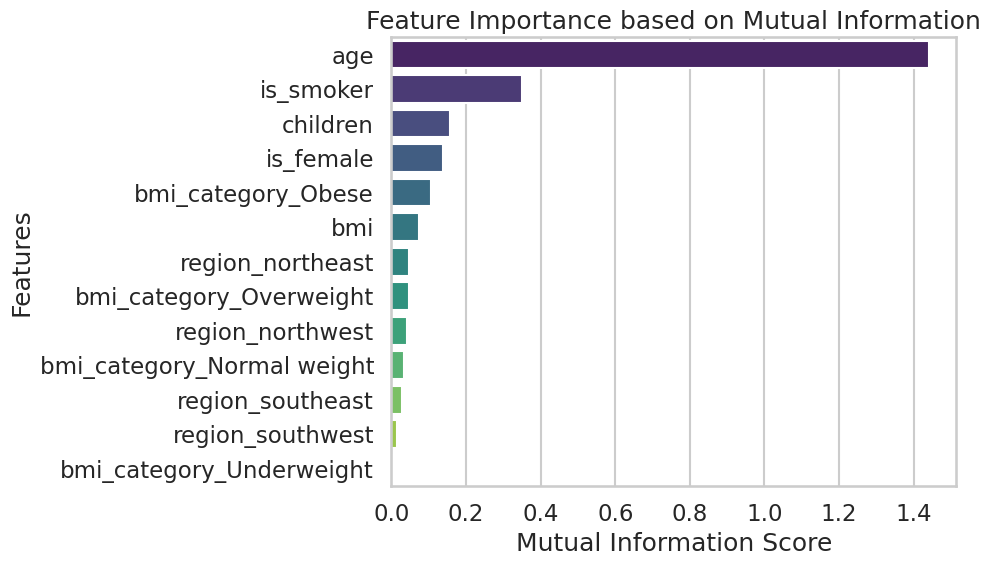

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_results,
    x="Mutual Information Score",
    y="Feature",
    palette="viridis"
    
)

plt.title("Feature Importance based on Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.tight_layout()

plt.show()

In [45]:
X_train = X_train[['age','is_smoker','children','is_female','bmi_category_Obese','bmi']]
X_test = X_test[['age','is_smoker','children','is_female','bmi_category_Obese','bmi']]

**Going with all the features for first model**

# Custom Model

In [46]:
from Linear_Regression import LinearRegressionScratch
from sklearn.metrics import r2_score

In [47]:
model = LinearRegressionScratch(
    learning_rate=0.0001,
    epochs=100000
)

In [48]:
model.fit(X_train, y_train)

In [49]:
predicted_y = model.predict(X_test)

**r2 score**

In [68]:
r2 = r2_score(y_test, predicted_y)
r2

0.7549406691395836

In [69]:
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
adjusted_r2

0.7493071213037119

**Mean squared error and root mean squared error**

In [52]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predicted_y)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)

MSE : 45031138.09545564
RMSE: 6710.5244277519505


In [53]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predicted_y)
print(f"MAE: {mae:.2f}")

MAE: 4782.16


In [54]:
np.mean(y_test)

np.float64(14272.007559287313)

In [55]:
np.mean(predicted_y)

np.float64(13845.974811525497)

# Visualization of actual vs predicted charges in model testing data

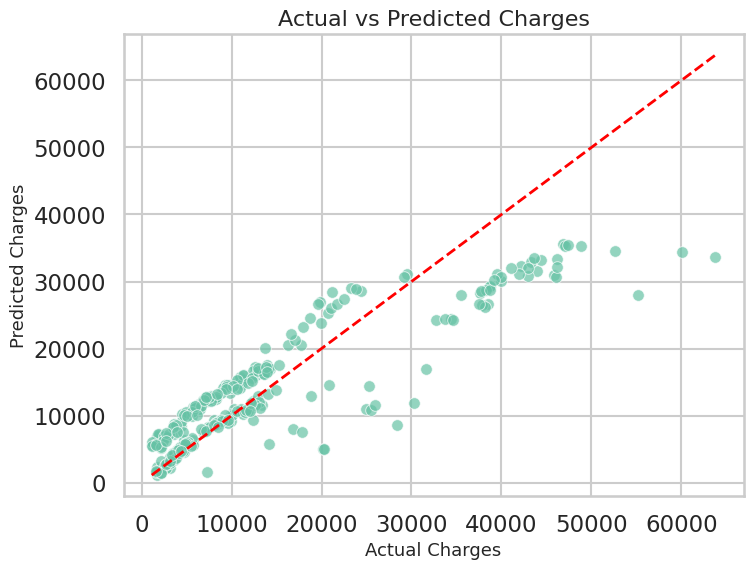

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=predicted_y,
    s=70,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title("Actual vs Predicted Charges", fontsize=16)
plt.xlabel("Actual Charges", fontsize=13)
plt.ylabel("Predicted Charges", fontsize=13)
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

# Comparison of Custom model and Sklearn model 

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
sklearn_model = LinearRegression()

sklearn_model.fit(X_train,y_train)

sklearn_prediction = sklearn_model.predict(X_test)

In [59]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [66]:
sk_r2 = r2_score(y_test, sklearn_prediction)
sk_r2

0.8035251301727891

In [73]:
sk_adjusted_r2 = 1 - (1 - sk_r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
sk_adjusted_r2

0.7990084664986004

In [70]:
sk_mse = mean_squared_error(y_test, sklearn_prediction)
sk_rmse = np.sqrt(sk_mse)

print("sk_MSE :", sk_mse)
print("sk_RMSE:", sk_rmse)

sk_MSE : 36103448.76243562
sk_RMSE: 6008.614546002733


In [71]:
from sklearn.metrics import mean_absolute_error

sk_mae = mean_absolute_error(y_test, sklearn_prediction)
print(f"sk_MAE: {sk_mae:.2f}")

sk_MAE: 4309.57


# Comparison df

In [74]:
comparison_df = pd.DataFrame({
    "R² Score": [r2, sk_r2],
    "Adjusted R²": [adjusted_r2, sk_adjusted_r2],
    "MSE": [mse, sk_mse],
    "RMSE": [rmse, sk_rmse],
    "MAE": [mae, sk_mae]
},
index=["Custom Model", "Sklearn Model"])

comparison_df


,R² Score,Adjusted R²,MSE,RMSE,MAE
Custom Model,0.754941,0.749307,4.503114e+07,6710.524428,4782.163217
Sklearn Model,0.803525,0.799008,3.610345e+07,6008.614546,4309.565181


# Conclusion

In this project, a **Linear Regression model was implemented completely from scratch using NumPy**, where the training process was built manually using **Gradient Descent** without relying on scikit-learn's `LinearRegression` class. The model learns the optimal weights and bias by iteratively minimizing the **Mean Squared Error (MSE)** cost function using a **learning rate of 0.0001** and **100,000 training epochs**.

Before training, the dataset was carefully preprocessed by handling categorical variables, scaling numerical features using **StandardScaler**, and selecting relevant features. This ensured that the model was trained on clean and meaningful data.

The custom implementation achieved an **R² Score of approximately 75.49%** and an **Adjusted R² Score of approximately 74.93%**, demonstrating that it was able to capture a significant portion of the relationship between the input features and insurance charges. The obtained **MSE**, **RMSE**, and **MAE** values further indicate that the model produces reasonably accurate predictions on unseen data.

To validate the correctness of the custom implementation, its performance was compared with **scikit-learn's LinearRegression** model. The scikit-learn implementation achieved an **R² Score of approximately 80.35%** and lower prediction errors across **MAE, MSE, and RMSE**, outperforming the custom model. This difference is expected because scikit-learn uses highly optimized numerical methods and linear algebra routines, whereas the custom model relies on Gradient Descent for parameter optimization.

Overall, this project provides both a practical implementation of Linear Regression and a solid understanding of the mathematical concepts behind machine learning, including **Gradient Descent, parameter optimization, cost minimization, and model evaluation**. Comparing the custom implementation with the scikit-learn model also helped validate the implementation while highlighting the performance advantages of optimized production-grade libraries.



